# Trečia užduotis: Vaizdų nuspalvinimas (Image Colorization)

**Versija:** 1.0 (2026-04-01)  
**Autorius:** Augustas Kniška  
**LSP numeris:** 2312054  
**Variantas:** Esami projekto duomenys iš `data/train/images`, `data/bee/images`, `data/castle/images`

## Tikslas
Sukurti modelį, kuris iš grayscale vaizdo (L kanalas) prognozuoja spalvinę informaciją (ab kanalai) ir atstato RGB vaizdą.

## Įgyvendinami reikalavimai
- Duomenų padalinimas į mokymo, validacijos ir testavimo aibes.
- Modelio mokymas.
- Metrikos testavimo aibei: PSNR, SSIM, MSE, MAE.
- Kelių testinių pavyzdžių vizualizacija: grayscale įvestis, modelio rezultatas, originalus vaizdas.
- Papildoma funkcija P2: REST API ir interaktyvi UI demonstracijai.

In [54]:
# %pip install numpy
# %pip install matplotlib
# %pip install Pillow
# %pip install torch
# %pip install scikit-image
# %pip install torch-directml
import os
import io
import random
from pathlib import Path
from dataclasses import dataclass
from typing import List, Tuple, Dict

import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from skimage import color
from skimage.metrics import peak_signal_noise_ratio, structural_similarity, mean_squared_error


# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

try:
    import torch_directml
    device = torch_directml.device()
    print(f'Naudojamas įrenginys: {device} (AMD DirectML)')
except Exception as exc:
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    print(f'DirectML nepavyko: {exc}')
    print(f'Naudojamas įrenginys: {device}')

Naudojamas įrenginys: privateuseone:0 (AMD DirectML)


In [79]:
@dataclass
class Config:
    data_dirs: List[Path]
    image_size: int = 256
    train_ratio: float = 0.7
    val_ratio: float = 0.15
    test_ratio: float = 0.15
    batch_size: int = 8
    num_epochs: int = 20
    learning_rate: float = 5e-4
    weight_decay: float = 1e-5
    num_workers: int = 0
    model_save_path: Path = Path('models/colorization_unet_best.pth')


cfg = Config(
    data_dirs=[
        Path('data/train/images'),
        Path('data/bee/images'),
        Path('data/castle/images'),
    ]
)

assert abs(cfg.train_ratio + cfg.val_ratio + cfg.test_ratio - 1.0) < 1e-9, 'Split proporcijos turi sudaryti 1.0'
cfg.model_save_path.parent.mkdir(parents=True, exist_ok=True)


def gather_image_paths(directories: List[Path]) -> List[Path]:
    image_paths: List[Path] = []
    valid_ext = {'.jpg', '.jpeg', '.png', '.bmp', '.webp'}
    for directory in directories:
        if not directory.exists():
            print(f'Perspėjimas: katalogas nerastas: {directory}')
            continue
        for path in directory.rglob('*'):
            if path.suffix.lower() in valid_ext:
                image_paths.append(path)
    return sorted(image_paths)


all_image_paths = gather_image_paths(cfg.data_dirs)
print(f'Rasta vaizdų: {len(all_image_paths)}')
if len(all_image_paths) == 0:
    raise RuntimeError('Nerasta vaizdų nurodytuose kataloguose.')

Rasta vaizdų: 2246


In [80]:
def split_paths(paths: List[Path], train_ratio: float, val_ratio: float, seed: int = 42) -> Tuple[List[Path], List[Path], List[Path]]:
    rng = random.Random(seed)
    shuffled = paths.copy()
    rng.shuffle(shuffled)

    n_total = len(shuffled)
    n_train = int(n_total * train_ratio)
    n_val = int(n_total * val_ratio)

    train_paths = shuffled[:n_train]
    val_paths = shuffled[n_train:n_train + n_val]
    test_paths = shuffled[n_train + n_val:]
    return train_paths, val_paths, test_paths


train_paths, val_paths, test_paths = split_paths(all_image_paths, cfg.train_ratio, cfg.val_ratio, seed=SEED)
print(f'Train: {len(train_paths)} | Val: {len(val_paths)} | Test: {len(test_paths)}')

Train: 1572 | Val: 336 | Test: 338


In [ ]:
class ColorizationDataset(Dataset):
    def __init__(self, paths, size=256):
        self.paths = paths
        self.transform = transforms.Compose([
            transforms.Resize((size, size)),
            transforms.RandomHorizontalFlip(),
        ])

    def __len__(self): return len(self.paths)

    def __getitem__(self, idx):
        img = Image.open(self.paths[idx]).convert('RGB')
        img = self.transform(img)
        img_lab = rgb2lab(np.array(img)).astype("float32")

        # Normalizacija: L į [0, 1], ab į [-1, 1]
        L = img_lab[:, :, 0:1] / 100.0
        ab = img_lab[:, :, 1:3] / 110.0

        return torch.tensor(L).permute(2, 0, 1), torch.tensor(ab).permute(2, 0, 1)


train_dataset = ColorizationDataset(train_paths, image_size=cfg.image_size)
val_dataset = ColorizationDataset(val_paths, image_size=cfg.image_size)
test_dataset = ColorizationDataset(test_paths, image_size=cfg.image_size)

train_loader = DataLoader(train_dataset, batch_size=cfg.batch_size, shuffle=True, num_workers=cfg.num_workers)
val_loader = DataLoader(val_dataset, batch_size=cfg.batch_size, shuffle=False, num_workers=cfg.num_workers)
test_loader = DataLoader(test_dataset, batch_size=cfg.batch_size, shuffle=False, num_workers=cfg.num_workers)

print(f'DataLoaderiai paruošti. Train batches: {len(train_loader)}, Val batches: {len(val_loader)}, Test batches: {len(test_loader)}')

DataLoaderiai paruošti. Train batches: 197, Val batches: 42, Test batches: 43


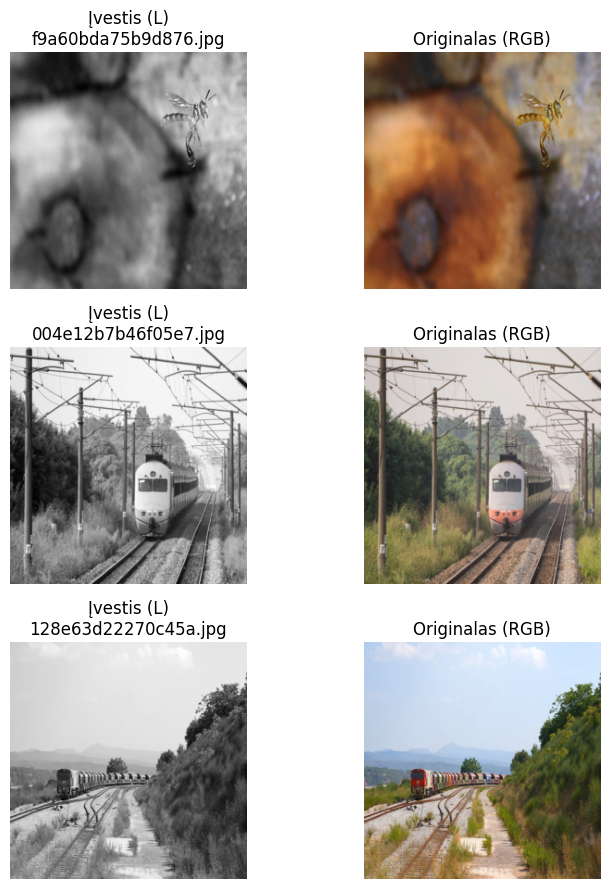

In [ ]:
def denormalize_lab_to_rgb(l_tensor: torch.Tensor, ab_tensor: torch.Tensor) -> np.ndarray:
    """
    Reconstruct RGB images from normalized LAB tensors.
    Handles both single images (C, H, W) and batches (B, C, H, W).
    """
    l_np = l_tensor.detach().cpu().numpy()
    ab_np = ab_tensor.detach().cpu().numpy()

    # Add batch dimension if needed
    if l_np.ndim == 3:
        l_np = l_np[None, ...]
    if ab_np.ndim == 3:
        ab_np = ab_np[None, ...]

    rgb_images = []
    for i in range(l_np.shape[0]):
        # Denormalize: reverse L/(50) - 1 and ab/128
        l_channel = (l_np[i].transpose(1, 2, 0) + 1.0) * 50.0
        ab_channels = ab_np[i].transpose(1, 2, 0) * 128.0
        
        # Reconstruct LAB and convert to RGB
        lab_image = np.concatenate([l_channel, ab_channels], axis=-1)
        rgb_image = np.clip(color.lab2rgb(lab_image), 0.0, 1.0)
        rgb_images.append(rgb_image)
    
    return np.stack(rgb_images, axis=0)


def show_dataset_samples(dataset: ColorizationDataset, n_samples: int = 3):
    fig, axes = plt.subplots(n_samples, 2, figsize=(8, 3 * n_samples))
    if n_samples == 1:
        axes = np.array([axes])

    for row in range(n_samples):
        l_tensor, ab_tensor, path = dataset[row]
        rgb = denormalize_lab_to_rgb(l_tensor, ab_tensor)[0]
        gray = ((l_tensor.squeeze(0).numpy() + 1.0) / 2.0)

        axes[row, 0].imshow(gray, cmap='gray')
        axes[row, 0].set_title(f'Įvestis (L)\n{Path(path).name}')
        axes[row, 0].axis('off')

        axes[row, 1].imshow(rgb)
        axes[row, 1].set_title('Originalas (RGB)')
        axes[row, 1].axis('off')

    plt.tight_layout()
    plt.show()


show_dataset_samples(train_dataset, n_samples=min(3, len(train_dataset)))

In [ ]:
import torch.nn as nn
import torch.optim as optim
from torchvision import transforms, models
from torch.utils.data import DataLoader, Dataset
from skimage.color import rgb2lab, lab2rgb
from skimage.metrics import peak_signal_noise_ratio, structural_similarity
from glob import glob
from PIL import Image

class ColorizationDataset(Dataset):
    def __init__(self, paths, size=256):
        self.paths = paths
        self.transform = transforms.Compose([
            transforms.Resize((size, size)),
            transforms.RandomHorizontalFlip(),
        ])

    def __len__(self): return len(self.paths)

    def __getitem__(self, idx):
        img = Image.open(self.paths[idx]).convert('RGB')
        img = self.transform(img)
        img_lab = rgb2lab(np.array(img)).astype("float32")

        # Normalizacija: L į [0, 1], ab į [-1, 1]
        L = img_lab[:, :, 0:1] / 100.0
        ab = img_lab[:, :, 1:3] / 110.0

        return torch.tensor(L).permute(2, 0, 1), torch.tensor(ab).permute(2, 0, 1)

class ColorizationNet(nn.Module):
    def __init__(self):
        super().__init__()
        resnet = models.resnet18(pretrained=True)

        # Encoder
        self.input_layer = nn.Conv2d(1, 64, kernel_size=7, stride=2, padding=3, bias=False)
        self.input_layer.weight.data = resnet.conv1.weight.data.sum(dim=1, keepdim=True)
        self.bn1, self.relu, self.maxpool = resnet.bn1, resnet.relu, resnet.maxpool

        self.layer1 = resnet.layer1 # 64 pz, 64x64
        self.layer2 = resnet.layer2 # 128 pz, 32x32
        self.layer3 = resnet.layer3 # 256 pz, 16x16
        self.layer4 = resnet.layer4 # 512 pz, 8x8

        # Decoder
        self.up1 = self._block(512, 256)           # 8->16
        self.up2 = self._block(256 + 256, 128)     # 16->32
        self.up3 = self._block(128 + 128, 64)      # 32->64
        self.up4 = self._block(64 + 64, 64)        # 64->128

        self.final = nn.Sequential(
            nn.Upsample(scale_factor=2, mode='bilinear', align_corners=True), # 128->256
            nn.Conv2d(64, 32, 3, padding=1), nn.ReLU(),
            nn.Conv2d(32, 2, 1), nn.Tanh()
        )

    def _block(self, in_c, out_c):
        return nn.Sequential(
            nn.Upsample(scale_factor=2, mode='bilinear', align_corners=True),
            nn.Conv2d(in_c, out_c, 3, padding=1), nn.BatchNorm2d(out_c), nn.ReLU()
        )

    def forward(self, x):
        x0 = self.relu(self.bn1(self.input_layer(x)))
        x1 = self.layer1(self.maxpool(x0))
        x2 = self.layer2(x1)
        x3 = self.layer3(x2)
        x4 = self.layer4(x3)

        d1 = self.up1(x4)
        d2 = self.up2(torch.cat([d1, x3], 1))
        d3 = self.up3(torch.cat([d2, x2], 1))
        d4 = self.up4(torch.cat([d3, x1], 1))
        return self.final(d4)

Bendras parametrų skaičius: 7,701,890
Mokomų parametrų skaičius: 7,701,890


In [ ]:

import torch.nn as nn
import torch.optim as optim
from torchvision import transforms, models
from torch.utils.data import DataLoader, Dataset
from skimage.color import rgb2lab, lab2rgb
from skimage.metrics import peak_signal_noise_ratio, structural_similarity
from glob import glob
from PIL import Image
import numpy as np

train_paths = glob("/content/data_split/train/*/*.jpg")
val_paths = glob("/content/data_split/val/*/*.jpg")

train_loader = DataLoader(ColorizationDataset(train_paths), batch_size=16, shuffle=True)
val_loader = DataLoader(ColorizationDataset(val_paths), batch_size=16)

model = ColorizationNet().to(device)
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=2e-4)

# Mokymas
epochs = 15
for epoch in range(epochs):
    model.train()
    total_loss = 0
    for L, ab in train_loader:
        L, ab = L.to(device), ab.to(device)
        optimizer.zero_grad()
        output = model(L)
        loss = criterion(output, ab)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    print(f"Epoch {epoch+1}/{epochs}, Loss: {total_loss/len(train_loader):.4f}")

# Metrikos
def evaluate(model, loader):
    model.eval()
    psnr_l, ssim_l, mse_l = [], [], []
    with torch.no_grad():
        for L, ab in loader:
            L, ab = L.to(device), ab.to(device)
            pred = model(L)
            for i in range(L.size(0)):
                real = ab[i].cpu().numpy().transpose(1,2,0)
                p = pred[i].cpu().numpy().transpose(1,2,0)
                mse_l.append(np.mean((real - p)**2))
                psnr_l.append(peak_signal_noise_ratio(real, p, data_range=2.0))
                ssim_l.append(structural_similarity(real, p, channel_axis=2, data_range=2.0))
    print(f"\nRezultatai: PSNR: {np.mean(psnr_l):.2f}, SSIM: {np.mean(ssim_l):.4f}, MSE: {np.mean(mse_l):.4f}")

evaluate(model, val_loader)

Įrenginys: privateuseone:0
Mokymas nuo nulio: 20 epochų | lr=0.0005 | lambda_l1=0.25 | lambda_mean=0.25 | lambda_chroma=0.1 | lambda_tv=0.05
Epoch 01/20 | train_loss: 0.07426 | val_loss: 0.06263 [SAVED]
Epoch 02/20 | train_loss: 0.06829 | val_loss: 0.06096 [SAVED]
Epoch 03/20 | train_loss: 0.06709 | val_loss: 0.06063 [SAVED]
Epoch 04/20 | train_loss: 0.06685 | val_loss: 0.06064
Epoch 05/20 | train_loss: 0.06625 | val_loss: 0.06065
Epoch 06/20 | train_loss: 0.06610 | val_loss: 0.06006 [SAVED]
Epoch 07/20 | train_loss: 0.06617 | val_loss: 0.05956 [SAVED]
Epoch 08/20 | train_loss: 0.06582 | val_loss: 0.05930 [SAVED]
Epoch 09/20 | train_loss: 0.06564 | val_loss: 0.05937
Epoch 10/20 | train_loss: 0.06502 | val_loss: 0.05900 [SAVED]
Epoch 11/20 | train_loss: 0.06397 | val_loss: 0.05869 [SAVED]
Epoch 12/20 | train_loss: 0.06361 | val_loss: 0.05788 [SAVED]
Epoch 13/20 | train_loss: 0.06381 | val_loss: 0.05718 [SAVED]
Epoch 14/20 | train_loss: 0.06279 | val_loss: 0.06007
Epoch 15/20 | train_los

C:\Users\knisk\AppData\Local\Temp\ipykernel_5580\3666268204.py:97: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(cfg.model_save_path, map_lo

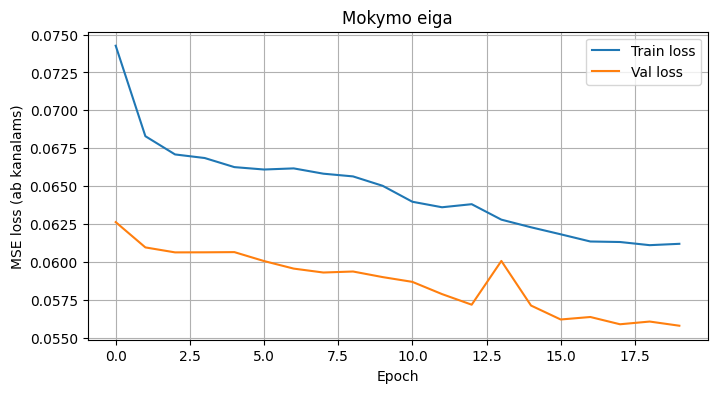

In [96]:
plt.figure(figsize=(8, 4))
plt.plot(history['train_loss'], label='Train loss')
plt.plot(history['val_loss'], label='Val loss')
plt.xlabel('Epoch')
plt.ylabel('MSE loss (ab kanalams)')
plt.title('Mokymo eiga')
plt.legend()
plt.grid(True)
plt.show()

C:\Users\knisk\AppData\Local\Temp\ipykernel_5580\2845414883.py:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(cfg.model_save_path, map_loc

Testavimo metrikos:
PSNR: -26.190359
SSIM: 0.817925
MSE: 793.202903
MAE: 116.564613


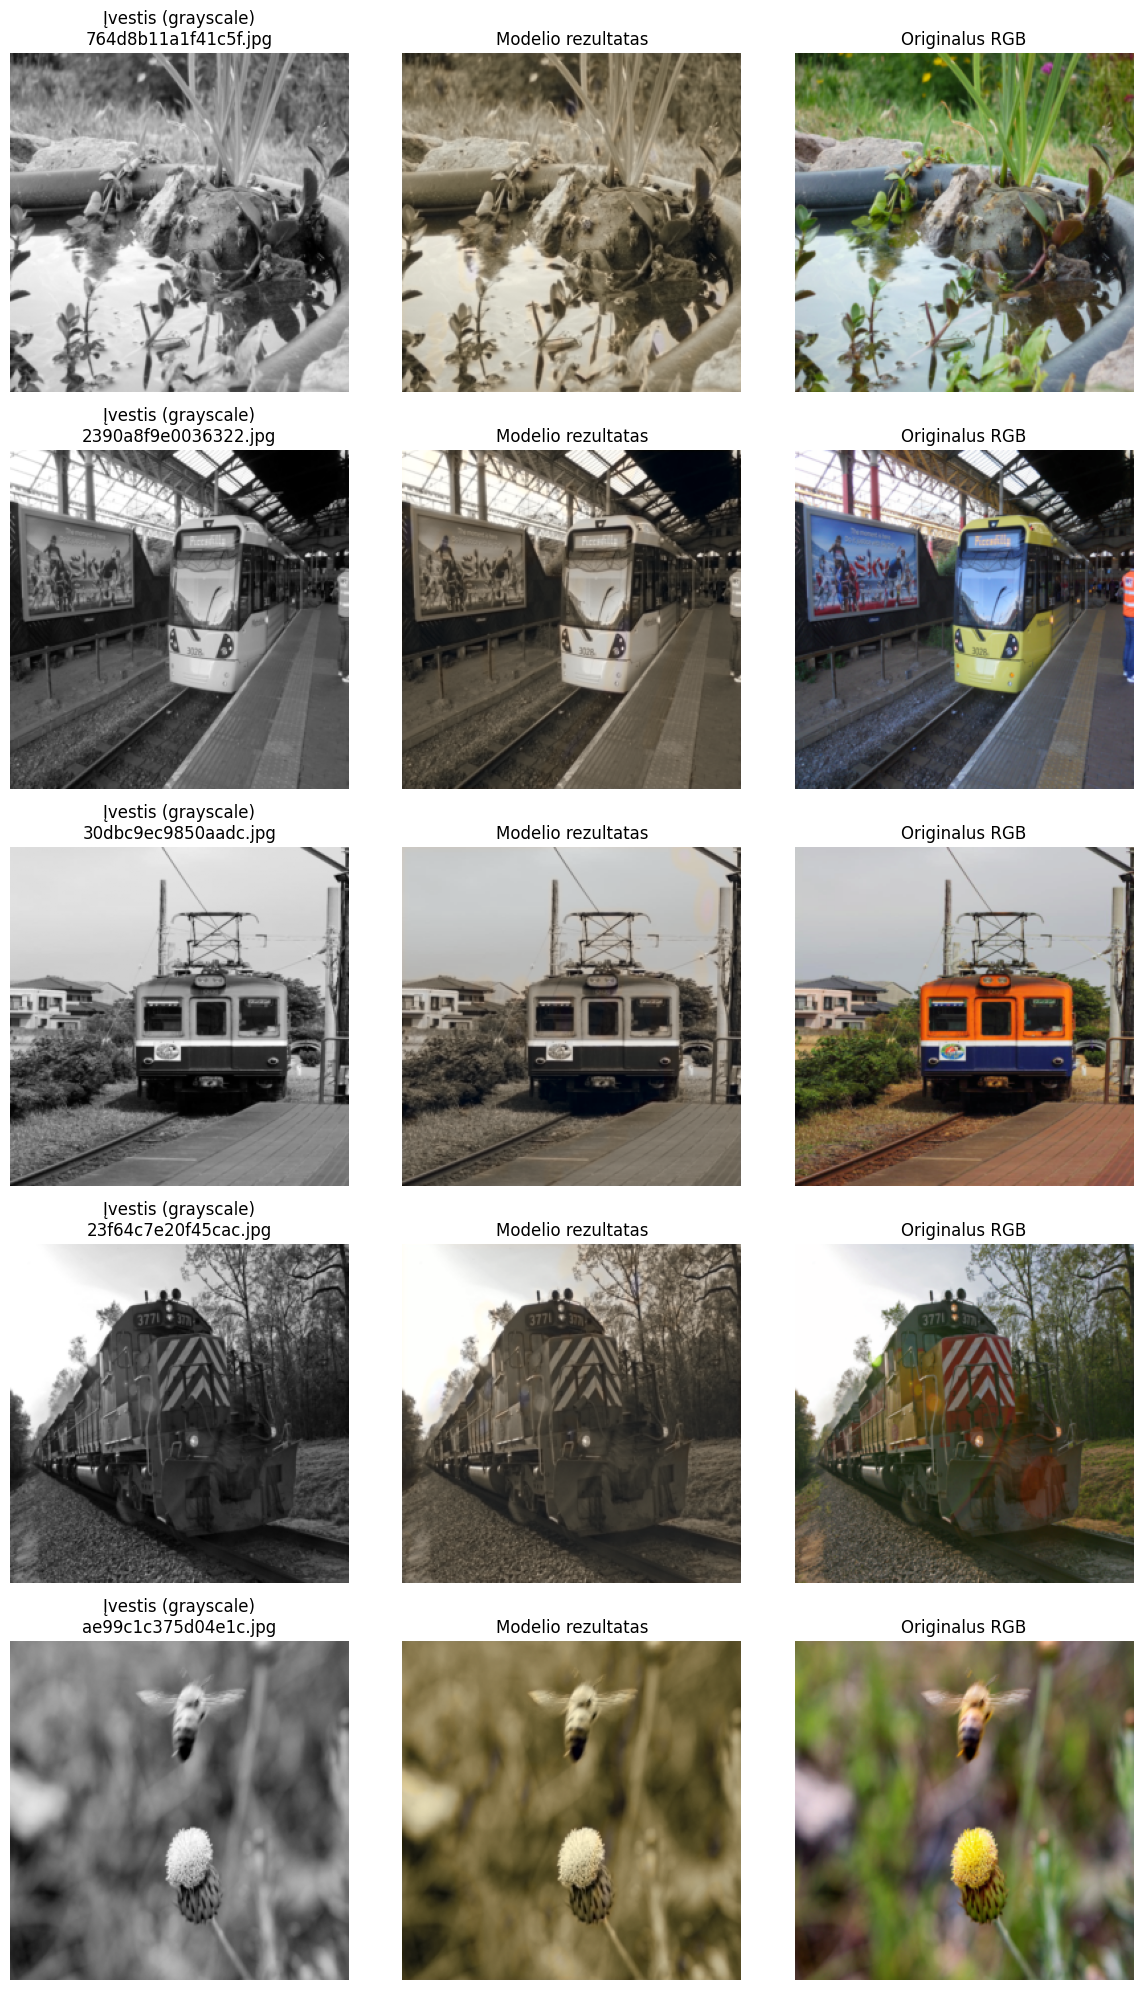

In [ ]:
import matplotlib.pyplot as plt

person_val_paths = [p for p in val_paths if 'person' in p]
tree_val_paths = [t for t in val_paths if 'tree' in t]
def plot_results(model, dataset, n=3):
    model.eval()
    plt.figure(figsize=(15, n * 5))
    for i in range(n):
        L, ab = dataset[i]
        with torch.no_grad():
            pred_ab = model(L.unsqueeze(0).to(device)).squeeze(0).cpu().numpy().transpose(1,2,0)

        L_np = L.numpy().transpose(1,2,0)
        real_ab = ab.numpy().transpose(1,2,0)

        def to_rgb(l, c):
            return lab2rgb(np.concatenate([l*100, c*110], axis=2))

        plt.subplot(n, 3, i*3+1); plt.imshow(L_np.squeeze(), cmap='gray'); plt.title("Nespalvotas")
        plt.subplot(n, 3, i*3+2); plt.imshow(to_rgb(L_np, pred_ab)); plt.title("Modelio spejimas")
        plt.subplot(n, 3, i*3+3); plt.imshow(to_rgb(L_np, real_ab)); plt.title("Originalas")
    plt.show()

plot_results(model, ColorizationDataset(val_paths), n=2)
plot_results(model, ColorizationDataset(person_val_paths), n=2)
plot_results(model, ColorizationDataset(tree_val_paths), n=2)

In [95]:
# Debug: Check what the model is predicting
print("=== Debugging Model Output ===")
model.eval()
with torch.no_grad():
    sample_l, sample_ab, _ = test_dataset[0]
    l_input = sample_l.unsqueeze(0).to(device)
    pred_ab = model(l_input).cpu().squeeze(0)
    
    print(f"Predicted ab min: {pred_ab.min().item():.4f}, max: {pred_ab.max().item():.4f}")
    print(f"Predicted ab mean: {pred_ab.mean().item():.4f}")
    print(f"Ground truth ab min: {sample_ab.min().item():.4f}, max: {sample_ab.max().item():.4f}")
    print(f"Ground truth ab mean: {sample_ab.mean().item():.4f}")
    print(f"Prediction close to zero? {(torch.abs(pred_ab) < 0.1).float().mean().item():.2%}")

print("\n=== Training Status ===")
if hasattr(model, 'training') and not model.training:
    print("✓ Model is in eval mode")
else:
    print("✗ Model might not be in eval mode")


=== Debugging Model Output ===
Predicted ab min: -0.0247, max: 0.1649
Predicted ab mean: 0.0486
Ground truth ab min: -0.3014, max: 0.6268
Ground truth ab mean: 0.0172
Prediction close to zero? 73.08%

=== Training Status ===
✓ Model is in eval mode


In [ ]:
# Helper function for inference on PIL Images

def colorize_pil_image(
    grayscale_image: Image.Image,
    model: nn.Module,
    image_size: int = 256,
) -> Image.Image:
    """
    Colorize a grayscale PIL image using the trained model.
    
    Args:
        grayscale_image: PIL Image in grayscale mode
        model: Trained colorization model
        image_size: Target size for inference
    
    Returns:
        Colorized PIL Image
    """
    model.eval()

    original_size = grayscale_image.size
    gray_resized = grayscale_image.convert('L').resize((image_size, image_size), Image.BILINEAR)
    gray_np = np.array(gray_resized).astype(np.float32) / 255.0

    # Convert grayscale to LAB and extract L channel
    gray_rgb = np.stack([gray_np, gray_np, gray_np], axis=-1)
    gray_lab = color.rgb2lab(gray_rgb)
    l_channel = gray_lab[:, :, 0:1] / 50.0 - 1.0

    l_tensor = torch.from_numpy(l_channel.transpose(2, 0, 1)).float().unsqueeze(0).to(device)

    with torch.no_grad():
        pred_ab = model(l_tensor).cpu().squeeze(0)

    # Reconstruct RGB from L and predicted ab
    pred_rgb = denormalize_lab_to_rgb(l_tensor.cpu().squeeze(0), pred_ab)[0]
    pred_img = Image.fromarray((pred_rgb * 255.0).astype(np.uint8))
    
    return pred_img.resize(original_size, Image.BILINEAR)

## P2: REST API ir interaktyvi UI

Žemiau pateikti minimalūs pavyzdžiai, kaip tą patį modelį naudoti:
- per REST API (FastAPI),
- per interaktyvią sąsają (Gradio).

Pastaba: šias celes galima paleisti po modelio apmokymo arba po modelio svorių įkėlimo iš `models/colorization_unet_best.pth`.

In [89]:
# Jei trūksta bibliotekų, atkomentuokite ir paleiskite:
%pip install fastapi uvicorn python-multipart gradio

try:
    from fastapi import FastAPI, UploadFile, File
    from fastapi.responses import StreamingResponse
    import uvicorn
    import gradio as gr
except ImportError:
    FastAPI = None
    UploadFile = None
    File = None
    StreamingResponse = None
    uvicorn = None
    gr = None
    print('P2 bibliotekos neįdiegtos, todėl API/UI celė yra neprivaloma.')

if FastAPI is not None:
    api_app = FastAPI(title='Image Colorization API')

    @api_app.post('/colorize')
    async def colorize_endpoint(file: UploadFile = File(...)):
        image_bytes = await file.read()
        input_image = Image.open(io.BytesIO(image_bytes)).convert('L')
        output_image = colorize_pil_image(input_image, model, image_size=cfg.image_size)

        output_buffer = io.BytesIO()
        output_image.save(output_buffer, format='PNG')
        output_buffer.seek(0)

        return StreamingResponse(output_buffer, media_type='image/png')

    # Paleidimas Jupyter aplinkoje (blokuoja šią celę, kol serveris veikia):
    # uvicorn.run(api_app, host='0.0.0.0', port=8000)

    def gradio_colorize(input_image: Image.Image) -> Image.Image:
        if input_image is None:
            return None
        return colorize_pil_image(input_image.convert('L'), model, image_size=cfg.image_size)

    demo = gr.Interface(
        fn=gradio_colorize,
        inputs=gr.Image(type='pil', label='Įkelkite grayscale vaizdą'),
        outputs=gr.Image(type='pil', label='Nuspalvintas rezultatas'),
        title='Image Colorization Demo',
        description='Įkelkite juodai baltą nuotrauką ir peržiūrėkite modelio nuspalvintą rezultatą.'
    )

    # Paleidimui:
    # demo.launch(share=False)


[notice] A new release of pip is available: 24.0 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip


  Using cached pydantic-2.13.3-py3-none-any.whl.metadata (108 kB)
  Using cached typing_inspection-0.4.2-py3-none-any.whl.metadata (2.6 kB)
  Using cached annotated_doc-0.0.4-py3-none-any.whl.metadata (6.6 kB)
  Using cached h11-0.16.0-py3-none-any.whl.metadata (8.3 kB)
  Using cached anyio-4.13.0-py3-none-any.whl.metadata (4.5 kB)
  Using cached httpx-0.28.1-py3-none-any.whl.metadata (7.1 kB)
     ---------------------------------------- 0.0/43.1 kB ? eta -:--:--
     ---------------------------------------- 43.1/43.1 kB 2.2 MB/s eta 0:00:00
  Using cached httpcore-1.0.9-py3-none-any.whl.metadata (21 kB)
  Using cached hf_xet-1.4.3-cp37-abi3-win_amd64.whl.metadata (4.9 kB)
  Using cached tqdm-4.67.3-py3-none-any.whl.metadata (57 kB)
  Using cached annotated_types-0.7.0-py3-none-any.whl.metadata (15 kB)
  Using cached shellingham-1.5.4-py2.py3-none-any.whl.metadata (3.5 kB)
  Using cached rich-15.0.0-py3-none-any.whl.metadata (18 kB)
  Using cached markdown_it_py-4.0.0-py3-none-any.whl

c:\Users\knisk\AppData\Local\Programs\Python\Python311\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Paleidimo seka atsiskaitymui

1. Paleisti importų ir konfigūracijos celes.
2. Paruošti duomenis ir DataLoaderius.
3. Apmokyti modelį arba įkelti jau išsaugotą modelį.
4. Paleisti testavimo metrikas (PSNR, SSIM, MSE, MAE).
5. Paleisti vizualizacijos celę su bent keliais testiniais pavyzdžiais.
6. Jei reikia P2 demonstracijos, paleisti REST API ir Gradio celes.

## Paaiškinimai, kuriuos reikia gebėti pateikti
- Duomenų paruošimas: RGB -> LAB, įvestis L, tikslas ab.
- Architektūra: U-Net encoder-decoder su skip jungtimis.
- Nuostolių funkcija: MSE tarp prognozuotų ir tikrų ab kanalų.
- Mokymas: epoch ciklas, validacija, geriausio checkpoint saugojimas.